# Data Schema EDA

Read-only exploration for Feature 05 data schema summaries. Run `uv run -m uni_rag_agent extract data-summaries` before using this notebook. This notebook reads generated app data only; it must not mutate SQLite, `Courses/`, source data files, or indexes.

In [1]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 140)
plt.style.use("default")

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError("Could not locate repository root")


REPO_ROOT = find_repo_root()
SQLITE_PATH = REPO_ROOT / "data" / "uni_rag.sqlite"
SQLITE_PATH

WindowsPath('D:/Projects/Uni RAG Agent/data/uni_rag.sqlite')

In [3]:
if not SQLITE_PATH.exists():
    raise FileNotFoundError(
        f"Missing SQLite database: {SQLITE_PATH}. Run storage init, inventory run, and extract data-summaries first."
    )

sqlite_uri = SQLITE_PATH.resolve().as_uri() + "?mode=ro"
connection = sqlite3.connect(sqlite_uri, uri=True)
connection.execute("PRAGMA query_only = ON")
connection.row_factory = sqlite3.Row

In [4]:
data_summaries = pd.read_sql_query(
    """
    SELECT
        files.id AS file_id,
        courses.name AS course_name,
        files.relative_path,
        files.filename,
        files.extension,
        files.size_bytes,
        files.index_status,
        files.reason_not_indexed,
        data_summaries.format,
        data_summaries.row_count,
        data_summaries.column_count,
        data_summaries.table_count,
        data_summaries.sheet_count,
        data_summaries.sample_json IS NOT NULL AS has_sample,
        data_summaries.created_at
    FROM files
    LEFT JOIN courses ON courses.id = files.course_id
    LEFT JOIN data_summaries ON data_summaries.file_id = files.id
    WHERE files.category = 'data_schema'
    ORDER BY files.relative_path
    """,
    connection,
)

data_schema_chunks = pd.read_sql_query(
    """
    SELECT
        chunks.id AS chunk_id,
        chunks.file_id,
        files.filename,
        files.relative_path,
        chunks.location_type,
        chunks.location_value,
        chunks.title,
        chunks.token_count,
        LENGTH(chunks.text) AS text_length
    FROM chunks
    JOIN files ON files.id = chunks.file_id
    WHERE chunks.source_type = 'data_schema'
    ORDER BY files.relative_path, chunks.chunk_index
    """,
    connection,
)

data_failures = data_summaries[data_summaries["index_status"].eq("failed")].copy()
data_summaries.head(), data_schema_chunks.head(), data_failures.head()

(   file_id course_name  \
 0      342    Data Eng   
 1      339    Data Eng   
 2      340    Data Eng   
 3      343    Data Eng   
 4      344    Data Eng   
 
                                                        relative_path  \
 0  Data Eng\Lab\assignments solutions\Datasets\DataPreprocessing.csv   
 1             Data Eng\Lab\assignments solutions\Datasets\chinook.db   
 2      Data Eng\Lab\assignments solutions\Datasets\customer_sales.db   
 3             Data Eng\Lab\assignments solutions\Datasets\input.json   
 4              Data Eng\Lab\assignments solutions\Datasets\train.csv   
 
                 filename extension  size_bytes index_status  \
 0  DataPreprocessing.csv      .csv         222      pending   
 1             chinook.db       .db      884736      pending   
 2      customer_sales.db       .db       10240      pending   
 3             input.json     .json         409      pending   
 4              train.csv      .csv      869537      pending   
 
   reason_

In [5]:
coverage_by_status = (
    data_summaries.groupby(["index_status"], dropna=False)
    .agg(files=("file_id", "count"), bytes=("size_bytes", "sum"))
    .reset_index()
)

coverage_by_format = (
    data_summaries.dropna(subset=["format"])
    .groupby("format")
    .agg(
        files=("file_id", "count"),
        rows=("row_count", "sum"),
        columns=("column_count", "sum"),
        chunks=(
            "file_id",
            lambda values: data_schema_chunks["file_id"].isin(values).sum(),
        ),
    )
    .reset_index()
)

coverage_by_status, coverage_by_format

(  index_status  files      bytes
 0      pending   5197  329202783,
 Empty DataFrame
 Columns: [format, files, rows, columns, chunks]
 Index: [])

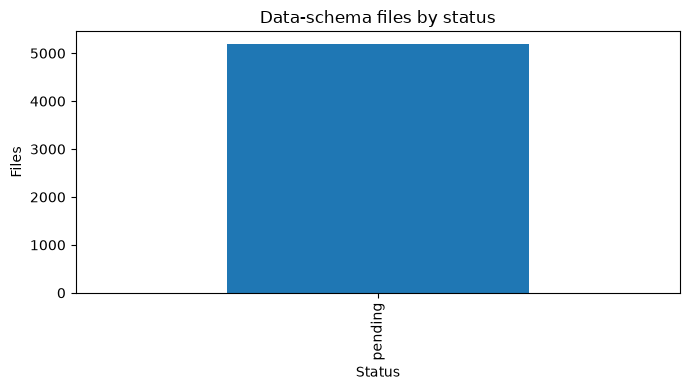

In [6]:
if coverage_by_status.empty:
    print("No data_schema files found. Run inventory first.")
else:
    ax = coverage_by_status.plot.bar(
        x="index_status", y="files", legend=False, figsize=(7, 4)
    )
    ax.set_title("Data-schema files by status")
    ax.set_xlabel("Status")
    ax.set_ylabel("Files")
    plt.tight_layout()

In [7]:
summary_counts = data_summaries.dropna(subset=["format"])
if summary_counts.empty:
    print("No persisted data summaries yet.")
else:
    axes = summary_counts[
        ["row_count", "column_count", "table_count", "sheet_count"]
    ].hist(bins=20, figsize=(10, 6))
    for axis_row in axes:
        for axis in axis_row:
            axis.set_ylabel("Files")
    plt.tight_layout()

No persisted data summaries yet.


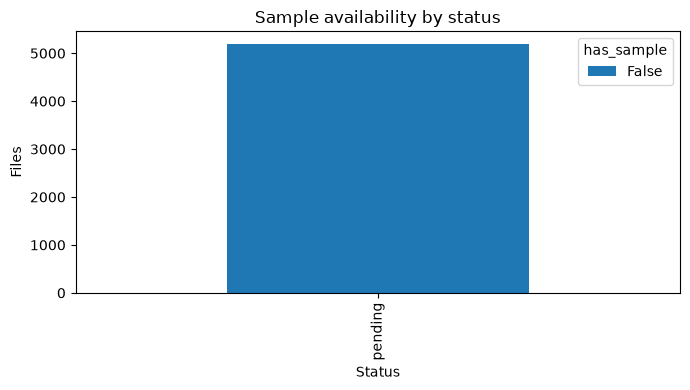

In [8]:
sample_coverage = (
    data_summaries.assign(
        has_sample=data_summaries["has_sample"].fillna(False).astype(bool)
    )
    .groupby(["index_status", "has_sample"], dropna=False)
    .size()
    .reset_index(name="files")
)
if sample_coverage.empty:
    print("No sample coverage data available.")
else:
    pivot = sample_coverage.pivot(
        index="index_status", columns="has_sample", values="files"
    ).fillna(0)
    ax = pivot.plot.bar(stacked=True, figsize=(7, 4))
    ax.set_title("Sample availability by status")
    ax.set_xlabel("Status")
    ax.set_ylabel("Files")
    plt.tight_layout()

In [9]:
if data_failures.empty:
    print("No failed data-summary files.")
else:
    failed_reasons = (
        data_failures["reason_not_indexed"]
        .fillna("unknown")
        .value_counts()
        .rename_axis("reason")
        .reset_index(name="files")
    )
    ax = failed_reasons.head(15).plot.barh(
        x="reason", y="files", legend=False, figsize=(9, 5)
    )
    ax.set_title("Failed data-summary reasons")
    ax.set_xlabel("Files")
    ax.set_ylabel("Reason")
    plt.tight_layout()
    failed_reasons.head(15)

No failed data-summary files.


In [10]:
connection.close()